# IT Support Ticket Classifier: DistilBERT Fine-Tuning

## 0. Clone repo

In [4]:
REPO_URL = "https://github.com/juliaysobel/aig-ticketclass.git"
REPO_DIR = "/content/repo"

!git clone {REPO_URL} {REPO_DIR}


Cloning into '/content/repo'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 21 (delta 1), reused 20 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 449.79 KiB | 26.46 MiB/s, done.
Resolving deltas: 100% (1/1), done.


## 1. Confirm GPU active

In [5]:
import torch

if not torch.cuda.is_available():
    print("WARNING: No GPU detected.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


GPU: Tesla T4
Using device: cuda


In [6]:
!pip install -q transformers accelerate


In [7]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizerFast, DistilBertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

torch.manual_seed(42)
np.random.seed(42)
sns.set_style("whitegrid")


## 2. Load data splits and baseline results

In [8]:
DATA_DIR = f"{REPO_DIR}/data"
RESULTS_DIR = f"{REPO_DIR}/results"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

with open(f"{RESULTS_DIR}/baseline_results.json") as f:
    baseline_results = json.load(f)

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
print(f"\nBaseline (Notebook 2) test macro-F1: {baseline_results['test_macro_f1']:.3f}")


Train: (350, 5) | Val: (75, 5) | Test: (75, 5)

Baseline (Notebook 2) test macro-F1: 0.680


## 3. Label encoding

In [9]:
# Convert category strings to integer class indices

LABEL_COL = 'category_final'
TEXT_COL = 'full_text'

label_encoder = LabelEncoder()
label_encoder.fit(train_df[LABEL_COL])
class_labels = list(label_encoder.classes_)
n_classes = len(class_labels)

print(f"Classes ({n_classes}): {class_labels}")

train_labels = label_encoder.transform(train_df[LABEL_COL])
val_labels = label_encoder.transform(val_df[LABEL_COL])
test_labels = label_encoder.transform(test_df[LABEL_COL])


Classes (8): ['Account', 'Communication', 'Hardware', 'Network', 'Other', 'RemoteWork', 'Security', 'Software']


## 4. Tokenizer and MAX_LENGTH

Note:
- EDA measured word count (176 words at the 95th percentile), but DistilBERT's `max_length` is set in tokens.
- Tokenize every training ticket with no truncation, look at the real token-length distribution, and set `MAX_LENGTH` from that


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1523 > 512). Running this sequence through the model will result in indexing errors


Token length stats (train set, real tokenizer, no truncation):
count     350.000000
mean       95.334286
std       104.178268
min        16.000000
25%        47.000000
50%        68.000000
75%       104.750000
max      1523.000000
dtype: float64
75th percentile: 104 tokens
90th percentile: 218 tokens
95th percentile: 261 tokens
99th percentile: 343 tokens
Max: 1523 tokens


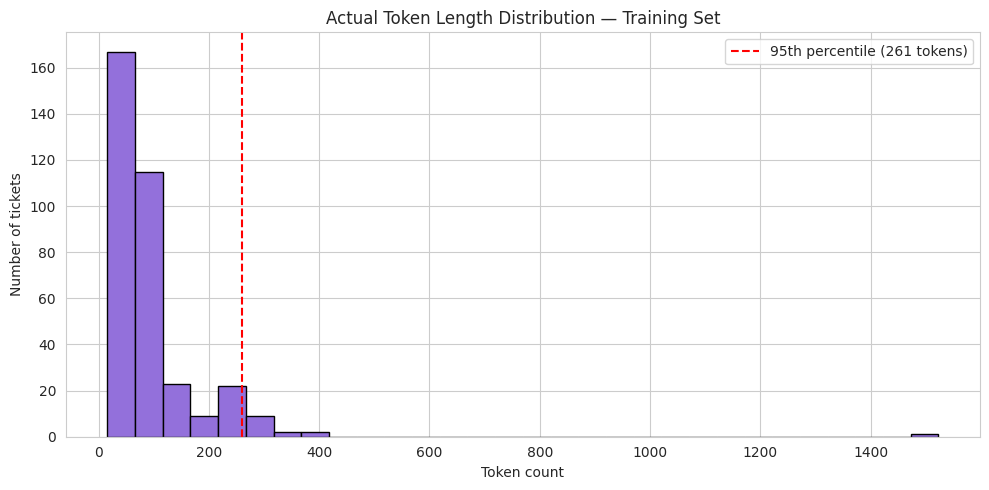


MAX_LENGTH set to 264 (measured 95th percentile = 261 tokens, rounded up to nearest multiple of 8)
input_ids shape: torch.Size([1, 264])
attention_mask shape: torch.Size([1, 264])


In [10]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

token_lengths = np.array([
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in train_df[TEXT_COL]
])

print("Token length stats (train set, real tokenizer, no truncation):")
print(pd.Series(token_lengths).describe())

for pct in [75, 90, 95, 99]:
    print(f"{pct}th percentile: {int(np.percentile(token_lengths, pct))} tokens")
print(f"Max: {token_lengths.max()} tokens")

p95_tokens = int(np.percentile(token_lengths, 95))

plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=30, color='mediumpurple', edgecolor='black')
plt.axvline(p95_tokens, color='red', linestyle='--',
            label=f'95th percentile ({p95_tokens} tokens)')
plt.title('Actual Token Length Distribution — Training Set')
plt.xlabel('Token count')
plt.ylabel('Number of tickets')
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/token_length_distribution.png", dpi=150)
plt.show()

# MAX_LENGTH = 95th percentile of REAL token counts, rounded up to the nearest
# multiple of 8 (minor GPU efficiency convention), capped at DistilBERT's
# absolute limit of 512 positions.
MAX_LENGTH = min(512, int(np.ceil(p95_tokens / 8) * 8))
print(f"\nMAX_LENGTH set to {MAX_LENGTH} "
      f"(measured 95th percentile = {p95_tokens} tokens, rounded up to nearest multiple of 8)")

sample = tokenizer(
    train_df[TEXT_COL].iloc[0], max_length=MAX_LENGTH,
    padding='max_length', truncation=True, return_tensors='pt'
)
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")


## 5. Dataset class

In [11]:
class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_ds = TicketDataset(train_df[TEXT_COL], train_labels, tokenizer, MAX_LENGTH)
val_ds = TicketDataset(val_df[TEXT_COL], val_labels, tokenizer, MAX_LENGTH)
test_ds = TicketDataset(test_df[TEXT_COL], test_labels, tokenizer, MAX_LENGTH)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Batches:\n train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches:
 train: 22, val: 5, test: 5


## 6. Model: pretrained DistilBERT encoder + custom classification head

1) DistilBERT reads the ticket text and turns it into a 768-number representation of what it means (understanding language)
2) The classification head takes that representation and maps it to one of the specific categories (understanding relation)

In [12]:
class TicketClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.3, encoder_name='distilbert-base-uncased'):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size  # 768 for distilbert-base

        self.dropout = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token representation

        x = self.dropout(cls_output)
        x = self.relu(self.dense(x))
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits


model = TicketClassifier(n_classes=n_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     66,959,624
Trainable parameters: 66,959,624


## 7. Training setup

Hyperparameter choices:
- **Learning rate 2e-5**: standard range for fine-tuning BERT-family models. Much higher risks destroying the pretrained knowledge; lower barely updates anything in a handful of epochs.
- **AdamW**: standard optimizer for transformer
  fine-tuning.
- **Linear warmup + decay schedule**: LR ramps up gradually for the first 10% of training steps then decays linearly to zero.
- **Gradient clipping (max norm 1.0)**: prevents occasional large gradients from destabilizing training
- **Early stopping (patience=2)**: stop training if validation loss hasn't improved for 2 consecutive epochs

In [13]:
NUM_EPOCHS = 20
PATIENCE = 2
LEARNING_RATE = 2e-5

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

## 8. Training loop


In [14]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # Validate
    model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            val_loss_total += loss.item() * labels.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered after epoch {epoch+1} "
                  f"(no val improvement for {PATIENCE} epochs).")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")


Epoch 1/20 | train_loss=2.0836 train_acc=0.143 | val_loss=2.0905 val_acc=0.107
Epoch 2/20 | train_loss=2.0640 train_acc=0.166 | val_loss=2.0763 val_acc=0.200
Epoch 3/20 | train_loss=2.0500 train_acc=0.294 | val_loss=2.0176 val_acc=0.427
Epoch 4/20 | train_loss=1.9602 train_acc=0.331 | val_loss=1.8623 val_acc=0.600
Epoch 5/20 | train_loss=1.7556 train_acc=0.529 | val_loss=1.6295 val_acc=0.587
Epoch 6/20 | train_loss=1.5021 train_acc=0.646 | val_loss=1.4321 val_acc=0.600
Epoch 7/20 | train_loss=1.2295 train_acc=0.689 | val_loss=1.2006 val_acc=0.613
Epoch 8/20 | train_loss=0.9811 train_acc=0.746 | val_loss=1.0113 val_acc=0.667
Epoch 9/20 | train_loss=0.7706 train_acc=0.834 | val_loss=0.8830 val_acc=0.747
Epoch 10/20 | train_loss=0.6287 train_acc=0.874 | val_loss=0.8594 val_acc=0.720
Epoch 11/20 | train_loss=0.4923 train_acc=0.909 | val_loss=0.8308 val_acc=0.720
Epoch 12/20 | train_loss=0.3952 train_acc=0.926 | val_loss=0.8177 val_acc=0.747
Epoch 13/20 | train_loss=0.2999 train_acc=0.951 |

## 9. Learning curves

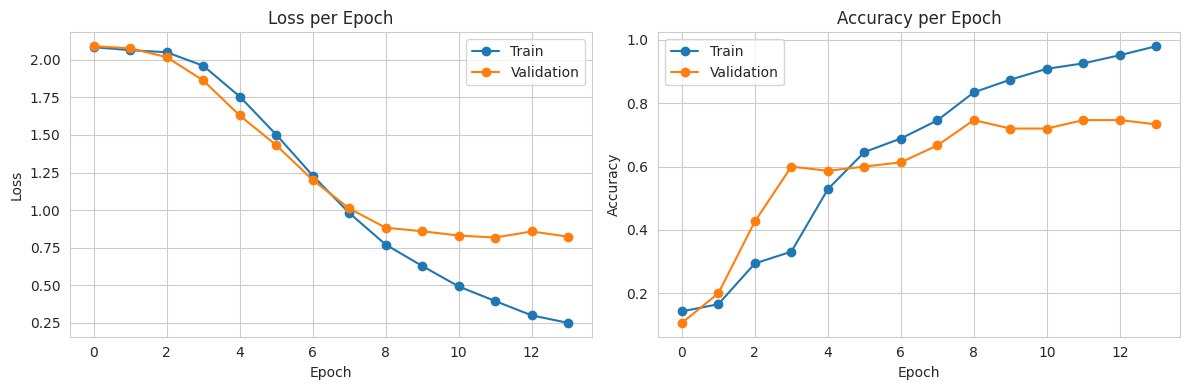

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Validation', marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Validation', marker='o')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/distilbert_learning_curves.png", dpi=150)
plt.show()


## 10. Load best checkpoint, then evaluate

In [16]:
model.load_state_dict(best_state_dict)
model.eval()

all_preds, all_labels_list, all_confidences = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        confs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())
        all_confidences.extend(confs.cpu().numpy())

acc = accuracy_score(all_labels_list, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels_list, all_preds, average='macro', zero_division=0
)

print(f"Test accuracy:        {acc:.3f}")
print(f"Test macro precision: {precision:.3f}")
print(f"Test macro recall:    {recall:.3f}")
print(f"Test macro F1:        {f1:.3f}")

print("\nFull per-class report:")
print(classification_report(
    all_labels_list, all_preds, target_names=class_labels, zero_division=0
))


Test accuracy:        0.773
Test macro precision: 0.698
Test macro recall:    0.752
Test macro F1:        0.706

Full per-class report:
               precision    recall  f1-score   support

      Account       0.56      1.00      0.71        10
Communication       0.57      1.00      0.73         4
     Hardware       0.67      0.67      0.67         3
      Network       0.90      0.90      0.90        10
        Other       0.00      0.00      0.00         4
   RemoteWork       1.00      1.00      1.00         3
     Security       1.00      0.71      0.83         7
     Software       0.89      0.74      0.81        34

     accuracy                           0.77        75
    macro avg       0.70      0.75      0.71        75
 weighted avg       0.79      0.77      0.76        75



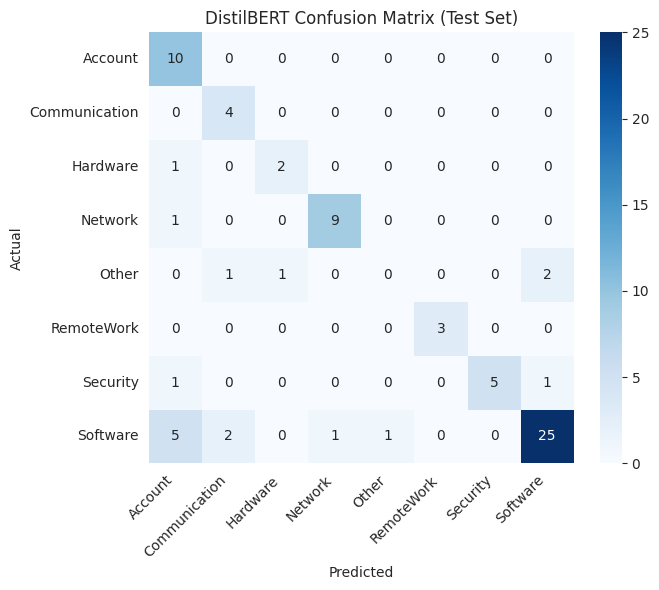

In [17]:
cm = confusion_matrix(all_labels_list, all_preds, labels=list(range(n_classes)))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DistilBERT Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/distilbert_confusion_matrix.png", dpi=150)
plt.show()


## 11. Baseline vs. DistilBERT comparison


                          Model  Accuracy  Macro Precision  Macro Recall  \
0  TF-IDF + Logistic Regression     0.720            0.655         0.743   
1       DistilBERT (fine-tuned)     0.773            0.698         0.752   

   Macro F1  
0     0.680  
1     0.706  


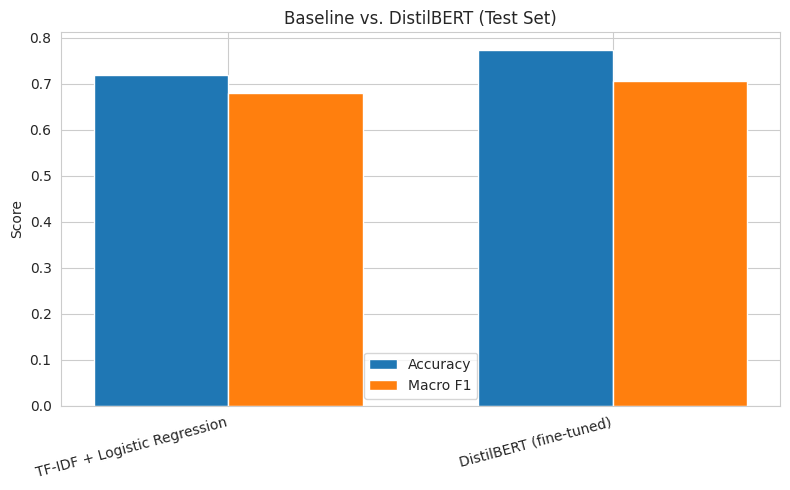

In [18]:
comparison_df = pd.DataFrame([
    {
        'Model': baseline_results['model_name'],
        'Accuracy': baseline_results['test_accuracy'],
        'Macro Precision': baseline_results['test_macro_precision'],
        'Macro Recall': baseline_results['test_macro_recall'],
        'Macro F1': baseline_results['test_macro_f1'],
    },
    {
        'Model': 'DistilBERT (fine-tuned)',
        'Accuracy': acc,
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
    },
])
print(comparison_df.round(3))

comparison_df.to_csv(f"{RESULTS_DIR}/model_comparison.csv", index=False)

plt.figure(figsize=(8, 5))
x = np.arange(len(comparison_df))
width = 0.35
metrics_to_plot = ['Accuracy', 'Macro F1']
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, comparison_df[metric], width, label=metric)
plt.xticks(x + width / 2, comparison_df['Model'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Baseline vs. DistilBERT (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model_comparison_chart.png", dpi=150)
plt.show()


## 12. Error analysis


In [19]:
test_texts = test_df[TEXT_COL].tolist()

misclassified_idx = [
    i for i, (p, l) in enumerate(zip(all_preds, all_labels_list)) if p != l
]

print(f"Misclassified: {len(misclassified_idx)} / {len(all_labels_list)} test examples\n")

n_to_show = max(20, len(misclassified_idx))  # show at least 20 if available
for i in misclassified_idx[:n_to_show]:
    true_label = class_labels[all_labels_list[i]]
    pred_label = class_labels[all_preds[i]]
    conf = all_confidences[i]
    print(f"[{i}] TRUE: {true_label}  |  PRED: {pred_label}  |  confidence: {conf:.2f}")
    print(f"    Text: {test_texts[i][:200]}")
    print()

if len(misclassified_idx) < 20:
    print(f"Note: only {len(misclassified_idx)} misclassified examples exist in this test set.")


Misclassified: 17 / 75 test examples

[0] TRUE: Other  |  PRED: Communication  |  confidence: 0.47
    Text: Requesting Instructions for Email Signature Setup. Hello there! As a Mobile User, I need instructions on configuring email signature settings on my device. Thanks in advance!

[12] TRUE: Software  |  PRED: Account  |  confidence: 0.72
    Text: Access Request for InDesign & Acrobat Tools. Hi team! Can I please request access to InDesign & Acrobat tools for my account? Thank you in advance.

[13] TRUE: Network  |  PRED: Account  |  confidence: 0.57
    Text: VPN Access Configuration for New Hire. Hey IT, 

Our new hire is having trouble connecting to the company VPN. They've followed the "New Hire 101 FAQ" guidelines and entered the correct credentials, b

[14] TRUE: Security  |  PRED: Account  |  confidence: 0.51
    Text: Digital Certificate Authentication Issue. Hi, I'm experiencing persistent issues with digital certificate authentication for secure email communication. It se

## 13. Save the model for the inference app

1) fine-tuned weights
2) tokenizer
3) config file (max length, class labels)

In [20]:
SAVE_DIR = "/content/distilbert_model"
os.makedirs(SAVE_DIR, exist_ok=True)

tokenizer.save_pretrained(SAVE_DIR)
torch.save(model.state_dict(), f"{SAVE_DIR}/pytorch_model.bin")

model_config = {
    'max_length': MAX_LENGTH,
    'hidden_size': model.encoder.config.hidden_size,
    'n_classes': n_classes,
    'class_labels': class_labels,
    'dropout': 0.3,
}
with open(f"{SAVE_DIR}/classifier_config.json", 'w') as f:
    json.dump(model_config, f, indent=2)

print(f"Saved tokenizer, model weights, and config to {SAVE_DIR}")


Saved tokenizer, model weights, and config to /content/distilbert_model


## 14. Push model


In [21]:
from google.colab import drive
import shutil
import os

SAVE_DIR = "/content/distilbert_model"
os.makedirs(SAVE_DIR, exist_ok=True)

drive.mount('/content/drive')

DRIVE_SAVE_DIR = '/content/drive/MyDrive/SENECA/Lab Notebooks/AIG230 NLP/Project/distilbert_model'
shutil.copytree(SAVE_DIR, DRIVE_SAVE_DIR, dirs_exist_ok=True)

print(f"Copied model to Google Drive: {DRIVE_SAVE_DIR}")
print("Download folder to your local machine (e.g. into models/distilbert/) "
      "when you build the inference app.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied model to Google Drive: /content/drive/MyDrive/SENECA/Lab Notebooks/AIG230 NLP/Project/distilbert_model
Download folder to your local machine (e.g. into models/distilbert/) when you build the inference app.
